# Exploration Notebook
## Letterboxd Dashboard
### Reid B.

# Import & Load 

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

ratings = pd.read_csv("data/ratings.csv")
diary = pd.read_csv("data/diary.csv")
watched = pd.read_csv("data/watched.csv")
watchlist = pd.read_csv("data/watchlist.csv")

for df in [ratings, diary, watched, watchlist]:
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    if 'year' in df.columns:
        df['year'] = df['year'].astype('Int64')

diary['watched_date'] = pd.to_datetime(diary['watched_date'], errors='coerce')
diary['date']         = pd.to_datetime(diary['date'], errors='coerce')
diary_dated           = diary.dropna(subset=['watched_date'])
ratings['decade']     = (ratings['year'] // 10 * 10).astype(str) + 's'

# Rating Distribution

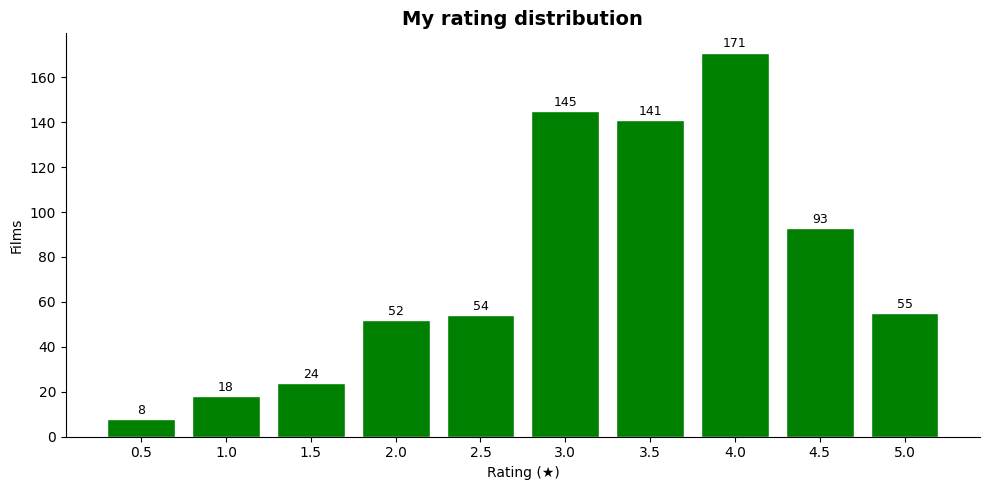

In [55]:
rc = ratings['rating'].value_counts().sort_index()

fig, ax = plt.subplots()
bars = ax.bar(rc.index.astype(str), rc.values, color='green', edgecolor='white')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('My rating distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating (★)')
ax.set_ylabel('Films')
plt.tight_layout()
plt.show()

# Header stats (All-time)

## Films Watched

In [56]:
# films watched 
films_watched = len(watched)
print(f'Films watched: {films_watched}')

Films watched: 1230


## Longest Streak

In [57]:
# streak (days)
watch_dates = (
    diary.watched_date.dt.date.drop_duplicates().sort_values().reset_index(drop=True)
)

longest_streak = 1
current_streak = 1

for i in range(1, len(watch_dates)):
    gap = (watch_dates[i] - watch_dates[i - 1]).days
    if gap == 1:
        current_streak += 1
        longest_streak = max(longest_streak, current_streak)
    else:
        current_streak = 1

print(f'Longest streak: {longest_streak} consecutive days')

Longest streak: 20 consecutive days


In [58]:
# Streak (weeks)
watch_weeks = (
    diary['watched_date'].dt.to_period('W').drop_duplicates().sort_values().reset_index(drop=True)
)

longest_week_streak = 1
current_week_streak = 1

for i in range(1, len(watch_weeks)):
    gap = watch_weeks[i].week - watch_weeks[i - 1].week
    year_gap = watch_weeks[i].year - watch_weeks[i - 1].year
    
    is_consecutive = (gap == 1) or (year_gap == 1 and gap < 0)
    
    if is_consecutive:
        current_week_streak += 1
        longest_week_streak = max(longest_week_streak, current_week_streak)
    else:
        current_week_streak = 1

print(f'Longest weekly streak: {longest_week_streak} consecutive weeks')

Longest weekly streak: 33 consecutive weeks


## Multi-film Days

In [59]:
films_per_day = diary.groupby(diary['watched_date'].dt.date)['name'].count()
multi_film_days = (films_per_day >= 2).sum()

print(f'Multi-film days: {multi_film_days}')

Multi-film days: 192


# Top films

## By Year


In [62]:
# by year - film (watched)
watched_year = watched.groupby("year")["name"].count()
# by year - rating
ratings_year = ratings.groupby("year")["name"].count()
# by year - diary
diary['log_year'] = diary['watched_date'].dt.year
diary_year = diary.groupby("log_year")["name"].count()

print(watched_year.head())
print(ratings_year.head())
print(diary_year.head())

year
1902    1
1922    1
1924    1
1928    1
1931    1
Name: name, dtype: int64
year
1924    1
1928    1
1931    1
1941    2
1948    1
Name: name, dtype: int64
log_year
2022     23
2023    278
2024    217
2025    274
2026    114
Name: name, dtype: int64


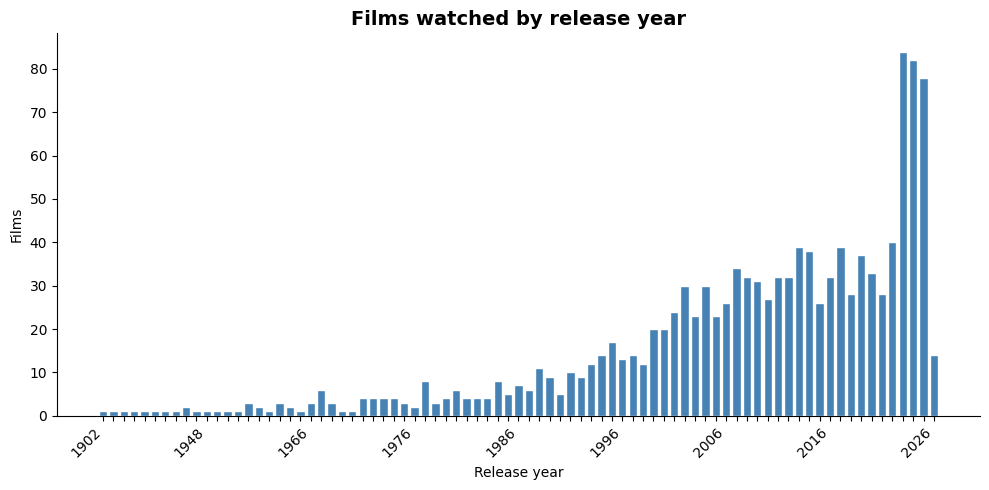

In [74]:
year_counts = watched['year'].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(year_counts.index.astype(str), year_counts.values, color='steelblue', edgecolor='white')
ax.set_title('Films watched by release year', fontsize=14, fontweight='bold')
ax.set_xlabel('Release year')
ax.set_ylabel('Films')

plt.xticks(rotation=45, ha='right')
#show every 5th label to avoid crowding
for i, label in enumerate(ax.get_xticklabels()):
    if i % 10 != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

In [75]:
year_ct = ratings.groupby("year")["rating"].count().sort_values(ascending=False)
year_avg = ratings.groupby("year")["rating"].mean().sort_values(ascending=False)

print(year_ct.head())
print(year_avg.head())

year
2023    74
2025    69
2024    67
2022    31
2017    29
Name: rating, dtype: int64
year
1924    5.00
1952    5.00
1966    5.00
1960    5.00
1975    4.75
Name: rating, dtype: float64


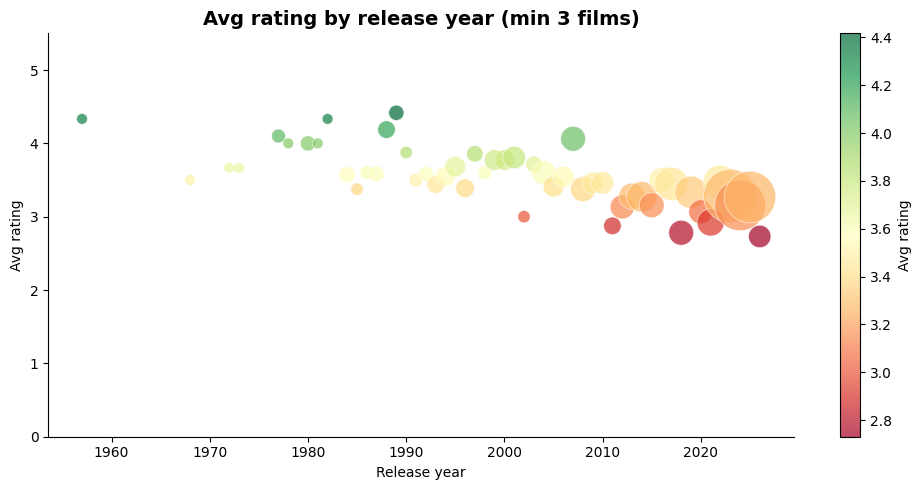

In [76]:
year_ratings = (
    ratings.groupby('year')['rating']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'avg_rating', 'count': 'films'})
    .query('films >= 3')
    .sort_values('year')
)

fig, ax = plt.subplots()
scatter = ax.scatter(
    year_ratings['year'],
    year_ratings['avg_rating'],
    s=year_ratings['films'] * 20,
    c=year_ratings['avg_rating'],
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='white',
    linewidths=0.5
)
plt.colorbar(scatter, ax=ax, label='Avg rating')
ax.set_title('Avg rating by release year (min 3 films)', fontsize=14, fontweight='bold')
ax.set_xlabel('Release year')
ax.set_ylabel('Avg rating')
ax.set_ylim(0, 5.5)
plt.tight_layout()
plt.show()

## highest rated decades

In [77]:
# by decade
ratings['decade'] = (ratings['year'] // 10 * 10).astype(str) + 's'
decade_ct = ratings.groupby("decade")["rating"].count().sort_values(ascending=False)
decade_avg = round(ratings.groupby("decade")["rating"].mean().sort_values(ascending=False), 2)

# Filter to decades with at least 20 films
min_films = 20
decade_ct = decade_ct[decade_ct >= min_films]
decade_avg = decade_avg[decade_avg.index.isin(decade_ct.index)]

print(decade_ct.head())
print(decade_avg.head())

decade
2020s    288
2010s    182
2000s    117
1990s     76
1980s     50
Name: rating, dtype: int64
decade
1970s    3.94
1980s    3.86
2000s    3.62
1990s    3.62
2010s    3.26
Name: rating, dtype: float64


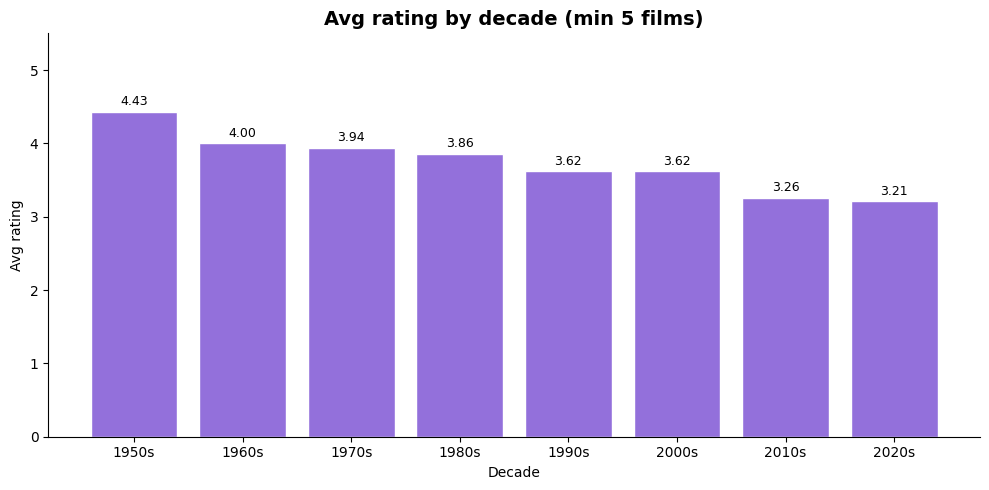

In [78]:
decade_stats = (
    ratings.groupby('decade')['rating']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'avg_rating', 'count': 'films'})
    .query('films >= 5')
    .sort_values('decade')
)

fig, ax = plt.subplots()
bars = ax.bar(decade_stats['decade'], decade_stats['avg_rating'].round(2),
              color='mediumpurple', edgecolor='white')

for bar, val in zip(bars, decade_stats['avg_rating']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{val:.2f}',
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Avg rating by decade (min 5 films)', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Avg rating')
ax.set_ylim(0, 5.5)
plt.tight_layout()
plt.show()

In [121]:
# most watched
diary.groupby('name').size().sort_values(ascending=False).head(20)

name
Scott Pilgrim vs. the World              8
Frances Ha                               6
Mulholland Drive                         4
Superman                                 4
Past Lives                               4
Blue Velvet                              4
Lady Bird                                4
Fargo                                    3
Rudolph the Red-Nosed Reindeer           3
The Perks of Being a Wallflower          3
Scott Pilgrim Takes Off                  3
Dune                                     3
Princess Mononoke                        3
The Wind Rises                           3
Hot Rod                                  3
Die Hard                                 3
National Lampoon's Christmas Vacation    3
Spirited Away                            3
Planes, Trains and Automobiles           3
The Worst Person in the World            3
dtype: int64

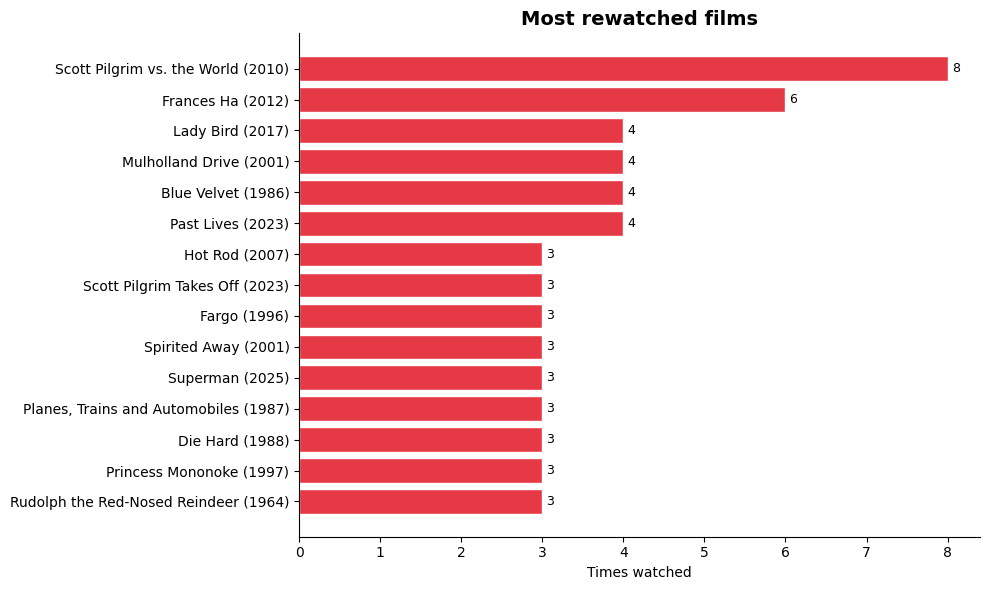

In [81]:
rewatched = (
    diary.groupby(['name', 'year'])
    .size()
    .reset_index(name='watches')
    .query('watches > 1')
    .sort_values('watches')
    .tail(15)
)
rewatched['label'] = rewatched['name'] + ' (' + rewatched['year'].astype(str) + ')'

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(rewatched['label'], rewatched['watches'], color='#e63946', edgecolor='white')

for bar in bars:
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        str(int(bar.get_width())),
        va='center', fontsize=9
    )

ax.set_title('Most rewatched films', fontsize=14, fontweight='bold')
ax.set_xlabel('Times watched')
plt.tight_layout()
plt.show()

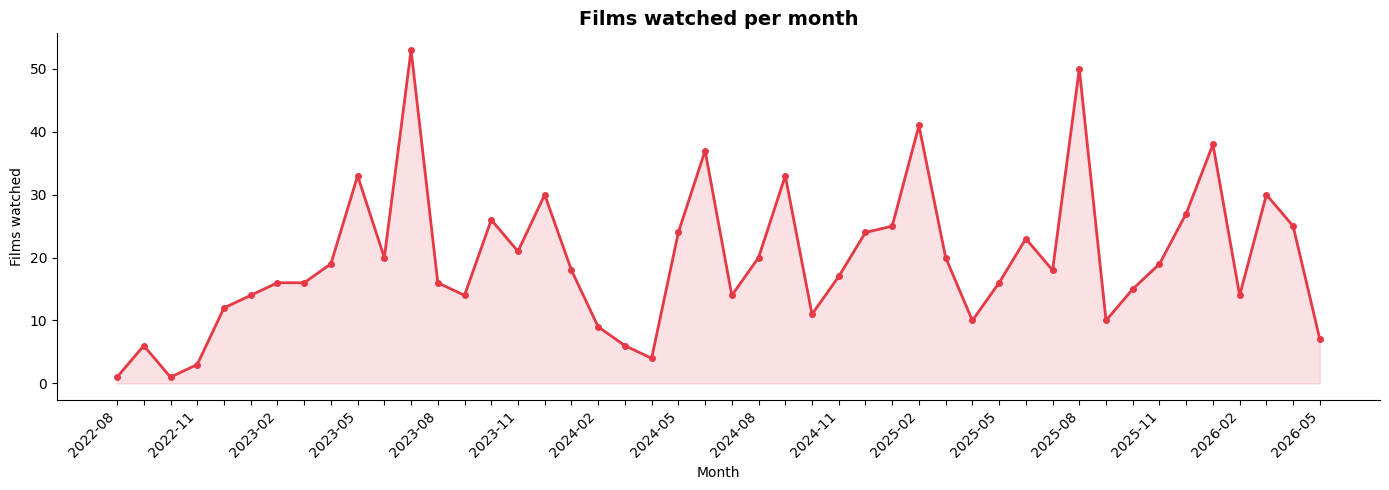

In [79]:
monthly = (
    diary_dated
    .groupby(diary_dated['watched_date'].dt.to_period('M'))
    .size()
    .reset_index(name='films')
)
monthly['watched_date'] = monthly['watched_date'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['watched_date'], monthly['films'],
        color='#e63946', linewidth=2, marker='o', markersize=4)
ax.fill_between(range(len(monthly)), monthly['films'], alpha=0.15, color='#e63946')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['watched_date'], rotation=45, ha='right')
# show every 3rd label
for i, label in enumerate(ax.get_xticklabels()):
    if i % 3 != 0:
        label.set_visible(False)
ax.set_title('Films watched per month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Films watched')
plt.tight_layout()
plt.show()

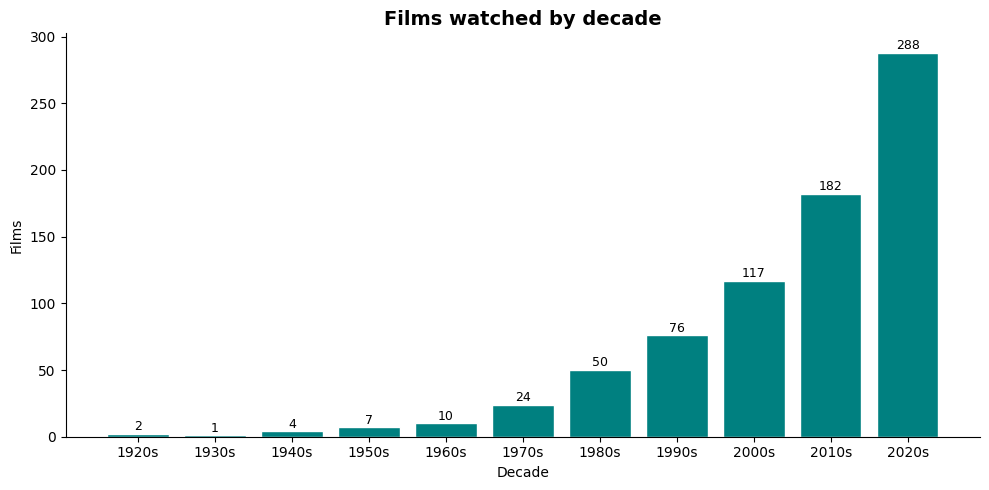

In [80]:
decade_counts = ratings['decade'].value_counts().sort_index()

fig, ax = plt.subplots()
bars = ax.bar(decade_counts.index, decade_counts.values, color='teal', edgecolor='white')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Films watched by decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Films')
plt.tight_layout()
plt.show()

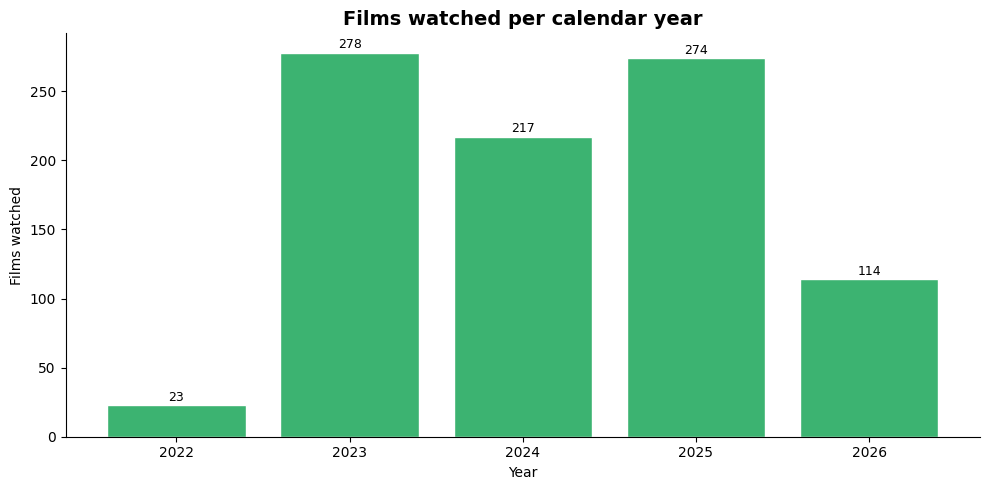

In [82]:
per_year = (
    diary_dated
    .groupby(diary_dated['watched_date'].dt.year)
    .size()
    .reset_index(name='films')
    .rename(columns={'watched_date': 'year'})
)

fig, ax = plt.subplots()
bars = ax.bar(per_year['year'].astype(str), per_year['films'],
              color='mediumseagreen', edgecolor='white')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Films watched per calendar year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Films watched')
plt.tight_layout()
plt.show()

## TBD for API
genres, countries, & languages
themes
list progress
collections

top cast
most watched, highest rated

top directors
most watched, highest rated

crew & studios
most watched, highest rated

world map

etc.


In [127]:
# Unrated watched films
watched_not_rated = set(watched["name"]) - set(ratings["name"])
print(f"Films watched but not rated: {len(watched_not_rated)}")

Films watched but not rated: 463
